In [22]:
from pathlib import Path
# /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/76_90000_samples_animal_206/summary_indiv_energies_for_exp_76_90000_samples_animal_206.csv
DATASET_NAME = "hcp_schaefer_100_dataset"
PROJECT_NAME ="05_second_big_overnight_run_10201" # 76_90000_samples_animal_206"
# DATASET_NAME = "suarez_MaMI_dataset" # hcp_schaefer_100_dataset" # suarez_MaMI_dataset" # hcp_schaefer_100_dataset" # suarez_MaMI_dataset"
# PROJECT_NAME = "76_90000_samples_animal_206" # 75_10000_samples_hopefully_no_lost_entries_gamma_minus0p1_to_1_animal_206_identical_version_just_without_minus_etc" # 76_90000_samples_animal_206" # 04_big_overnight_run" # 1_first_bigger_run_animal_0" # 76_90000_samples_animal_206" # 60_generally_finer_search_animal_0" # 26_testing_4_KS_folders_why_so_fast" # #  "2423_24rough_combined" # 24_testing_4_KS_folders_rougher_grid" # 20_sweep_with_individual_connectomes_eta_-7_and_gamma_-0.2"
# DATASET_NAME = "hcp_schaefer_100_dataset" # suarez_MaMI_dataset" # hcp_schaefer_100_dataset" # suarez_MaMI_dataset"
# mode = "portrait" # "energy"
mode = "energy"

base_output_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output")
project_path = base_output_path / "gnm" / DATASET_NAME / PROJECT_NAME
save_path_divergence = project_path / "figures_divergence"

save_path_divergence.mkdir(parents=True, exist_ok=True)

add_further_evals = True # only use for 76, to add 75 into it... -> not helpful, as "random seed" setting led to both sampling sequences being identical...

In [23]:
# from notebook_setup import setup
from vizman import viz
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)


viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

# from kaysons_visual_config import * # Kayson's file. 
from pypalettes import load_cmap
cmap = load_cmap("Aurora")

from src.visualization.find_and_plot_closest_connectome import find_closest_connectome

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

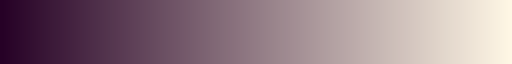

In [24]:
cmap = default_cmaps["metric_purple_beige"]
# cmap = default_cmaps["energy_blue_beige"].reversed()
cmap

In [25]:
# file_emp_connectome_estimated_eta_and_gamma = project_path / "min_energy_results.csv"
file_emp_connectome_estimated_eta_and_gamma = project_path / f"min_{mode}_results.csv"
df_best_eta_gamma = pd.read_csv(file_emp_connectome_estimated_eta_and_gamma)

df_metrics = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{DATASET_NAME}/{PROJECT_NAME}/all_metrics_for_{PROJECT_NAME}.csv") # /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/01_first_bigger_run_animal_0/all_metrics_for_01_first_bigger_run_animal_0.csv")

df_portraits = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{DATASET_NAME}/{PROJECT_NAME}/summary_indiv_portrait_for_exp_{PROJECT_NAME}.csv")
df_energies = pd.read_csv(f"/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/{DATASET_NAME}/{PROJECT_NAME}/summary_indiv_energies_for_exp_{PROJECT_NAME}.csv")

In [26]:
# if add_further_evals: 
#     df_75_further_metrics = pd.read_csv("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/75_10000_samples_hopefully_no_lost_entries_gamma_-0p1_to_1_animal_206/all_metrics_for_75_10000_samples_hopefully_no_lost_entries_gamma_-0p1_to_1_animal_206_updated.csv")
#     df_metrics = pd.concat([df_metrics, df_75_further_metrics], ignore_index=True)

# Is not of any use, as sampling is random but seed was identical! 

In [27]:
len(df_metrics)  # 90000
# len(df_75_further_metrics) # 23425


17144

In [28]:
# df_best_eta_gamma.loc[206]
df_portraits.head()

,network_index,filename,eta,gamma,id,PortraitDiv_indiv_0
0,0,net_eta2.77999997138977_gamma0.416999995708465...,2.78,0.417,0,0.702584
1,1,net_eta1.899999976158142_gamma0.46099999547004...,1.90,0.461,0,0.811428
2,2,net_eta2.009999990463256_gamma-0.0230000019073...,2.01,-0.023,0,0.516518
3,3,net_eta2.450000047683716_gamma-0.0560000017285...,2.45,-0.056,0,0.556124
4,4,net_eta2.230000019073486_gamma-0.0890000015497...,2.23,-0.089,0,0.568281


Text(0, 0.5, 'Gamma')

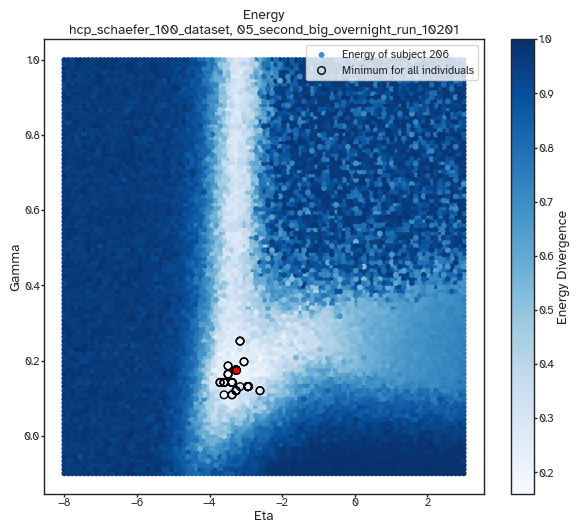

In [29]:
plt.figure(figsize=(viz.cm_to_inch((18,15))))

id = 0

if mode == "portrait":
    df = df_portraits.copy() 
    important_parameter = f"PortraitDiv_indiv_{id}" # subject_{id}"
elif mode == "energy":
    df = df_energies.copy()
    important_parameter = f"MaxCrit_indiv_{id}"
else: 
    print("Mode not recognized")

df_avg = df.groupby(['eta', 'gamma'], as_index=False).agg({
    important_parameter: 'mean'
})

plt.scatter(df["eta"], df["gamma"], c=df[important_parameter], alpha=1, s=10, cmap="Blues", label=f"{mode.capitalize()} of subject {206}")

plt.colorbar(label=f"{mode.capitalize()} Divergence")

plt.scatter(
    df_best_eta_gamma["eta"],
    df_best_eta_gamma["gamma"],
    c=None, # "cyan",
    alpha=1,
    edgecolors="black", 
    linewidths=1, 
    facecolors='none',
    s=30,
    label="Minimum for all individuals",
)   


plt.scatter(
    df_best_eta_gamma.loc[id, "eta"],
    df_best_eta_gamma.loc[id, "gamma"],
    c="red",
    alpha=1,
    edgecolors="black", 
    linewidths=1, 
    s=30)

plt.title(f"{mode.capitalize()}\n{DATASET_NAME}, {PROJECT_NAME}")

plt.legend(loc="upper right") #  bbox_to_anchor=(0,0)) # , fontsize=12)
x_label = "Eta"
y_label = "Gamma"
plt.xlabel(x_label)
plt.ylabel(y_label)

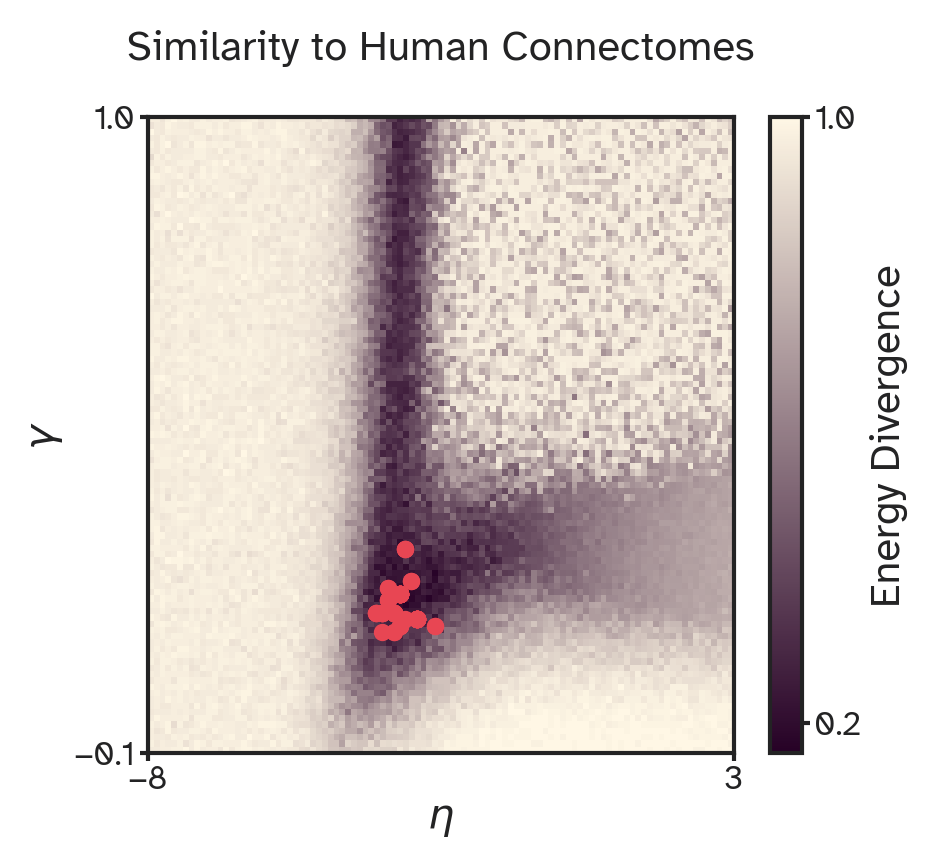

In [30]:
plt.figure(figsize=viz.cm_to_inch((8,7)), dpi=300)

id = 0

if mode == "portrait":
    df = df_portraits.copy()
    important_parameter = f"PortraitDiv_indiv_{id}"
elif mode == "energy":
    df = df_energies.copy()
    important_parameter = f"MaxCrit_indiv_{id}"
else:
    raise ValueError("Mode not recognized")

if PROJECT_NAME == "76_90000_samples_animal_206":
    # Divide the entire grid into 100x100 points and round each point to the nearest grid point
    eta_min = df["eta"].min()
    eta_max = df["eta"].max()
    gamma_min = df["gamma"].min()
    gamma_max = df["gamma"].max()
    df["eta_normalized"] = (df["eta"] - eta_min) / (eta_max - eta_min)
    df["gamma_normalized"] = (df["gamma"] - gamma_min) / (gamma_max - gamma_min)
    df["eta"] = df["eta_normalized"].round(2) * (eta_max - eta_min) + eta_min
    df["gamma"] = df["gamma_normalized"].round(2) * (gamma_max - gamma_min) + gamma_min


# elif PROJECT_NAME == "05_second_big_overnight_run_10201":
    # Average over individuals for each (eta, gamma)
df_avg = (
    df.groupby(["eta", "gamma"], as_index=False)[important_parameter]
    .mean()
)

# Pivot to 2D grid for imshow
Z = (
    df_avg.pivot(index="gamma", columns="eta", values=important_parameter)
          .sort_index()
          .sort_index(axis=1)
)

etas = Z.columns.to_numpy()
gammas = Z.index.to_numpy()

im = plt.imshow(
    Z.values,
    origin="lower",
    extent=[etas[0], etas[-1], gammas[0], gammas[-1]],
    aspect="auto",
    cmap=cmap,
)

cbar = plt.colorbar(im)
cbar.set_label(f"{mode.capitalize()} Divergence")
# make that cbar only shows the first and last tick with maximum 1 decimal place
z_val_w_o_nan = Z.values[~np.isnan(Z.values)]
cbar.set_ticks([np.ceil(z_val_w_o_nan.min()*10)/10, np.floor(z_val_w_o_nan.max()*10)/10])

# # Overlay minima (all individuals)
# plt.scatter(
#     df_best_eta_gamma.loc[id, "eta"],
#     df_best_eta_gamma.loc[id, "gamma"],
#     c=default_colors["warms"]["LECKER_RED"],
#     alpha=1,
#     # edgecolors="black", 
#     # linewidths=1, 
#     s=20)

# Overlay minima (all individuals)
plt.scatter(
    df_best_eta_gamma["eta"],
    df_best_eta_gamma["gamma"],
    c=default_colors["warms"]["LECKER_RED"],
    alpha=1,
    # edgecolors="black", 
    # linewidths=1, 
    s=10)


# # Highlight subject `id`
# plt.scatter(
#     df_best_eta_gamma.loc[id, "eta"],
#     df_best_eta_gamma.loc[id, "gamma"],
#     c="red",
#     edgecolors="black",
#     linewidths=1,
#     s=5,
#     label=f"Subject {id}",
# )


# Only write the first and last tick of the x and y axis
plt.xticks([etas[0], etas[-1]])
plt.yticks([gammas[0], gammas[-1]])

# Write greek letters for labels
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\gamma$")

# plt.title(f"{mode.capitalize()}\n{DATASET_NAME}, {PROJECT_NAME}")
if PROJECT_NAME == "76_90000_samples_animal_206": 
    plt.title(f"Similarity to Animal 206")
if PROJECT_NAME == "05_second_big_overnight_run_10201": 
    plt.title(f"Similarity to Human Connectomes\n")
# plt.xlabel("Eta")
# plt.ylabel("Gamma")
# plt.legend(loc="upper right")

# plt.tight_layout()


Text(0, 0.5, '$\\gamma$')

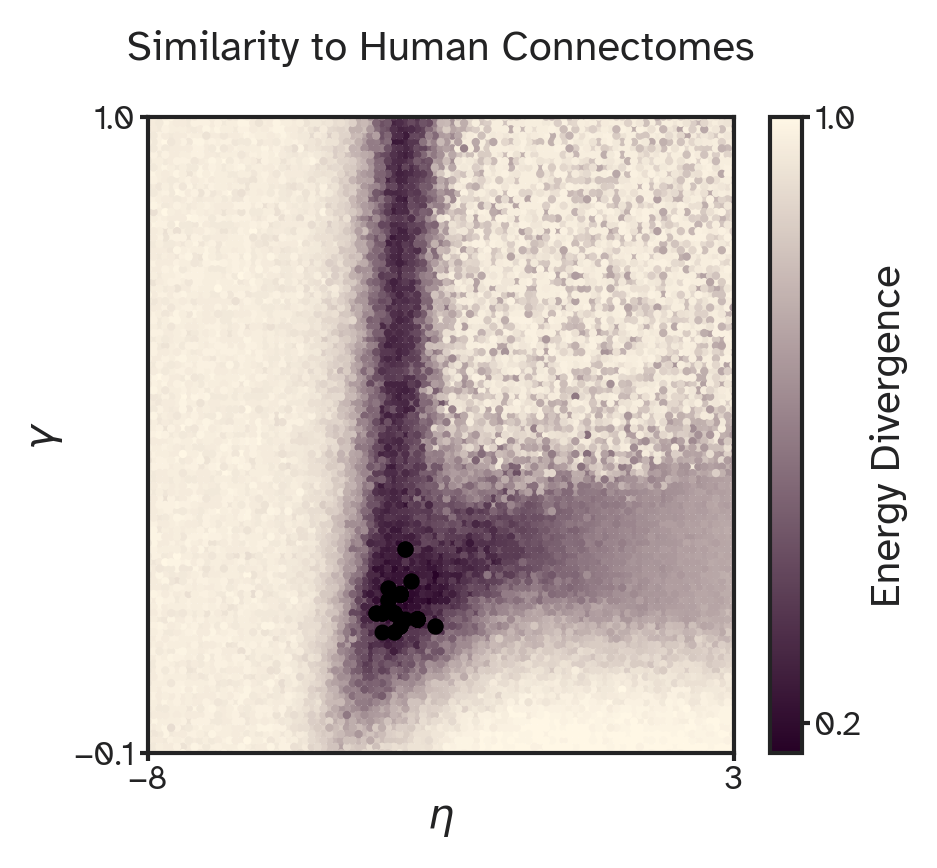

In [31]:
plt.figure(figsize=viz.cm_to_inch((8,7)), dpi=300)

id = 0

if mode == "portrait":
    df = df_portraits.copy()
    important_parameter = f"PortraitDiv_indiv_{id}"
elif mode == "energy":
    df = df_energies.copy()
    important_parameter = f"MaxCrit_indiv_{id}"
else:
    raise ValueError("Mode not recognized")

# if PROJECT_NAME == "76_90000_samples_animal_206":
#     # Divide the entire grid into 100x100 points and round each point to the nearest grid point
#     eta_min = df["eta"].min()
#     eta_max = df["eta"].max()
#     gamma_min = df["gamma"].min()
#     gamma_max = df["gamma"].max()
#     df["eta_normalized"] = (df["eta"] - eta_min) / (eta_max - eta_min)
#     df["gamma_normalized"] = (df["gamma"] - gamma_min) / (gamma_max - gamma_min)
#     df["eta"] = df["eta_normalized"].round(2) * (eta_max - eta_min) + eta_min
#     df["gamma"] = df["gamma_normalized"].round(2) * (gamma_max - gamma_min) + gamma_min



# Average over individuals for each (eta, gamma)
df_avg = (
    df.groupby(["eta", "gamma"], as_index=False)[important_parameter]
    .mean()
)

# Pivot to 2D grid for imshow
Z = (
    df_avg.pivot(index="gamma", columns="eta", values=important_parameter)
          .sort_index()
          .sort_index(axis=1)
)

etas = Z.columns.to_numpy()
gammas = Z.index.to_numpy()

# im = plt.imshow(
#     Z.values,
#     origin="lower",
#     extent=[etas[0], etas[-1], gammas[0], gammas[-1]],
#     aspect="auto",
#     cmap=cmap,
# )

im = plt.scatter(x=df["eta"],
                 y=df["gamma"], 
                 c=df[important_parameter],
                 s=1, 
                 cmap=cmap,
                 )

cbar = plt.colorbar(im)
cbar.set_label(f"{mode.capitalize()} Divergence")
# make that cbar only shows the first and last tick with maximum 1 decimal place
z_val_w_o_nan = Z.values[~np.isnan(Z.values)]
cbar.set_ticks([np.ceil(z_val_w_o_nan.min()*10)/10, np.floor(z_val_w_o_nan.max()*10)/10])

if PROJECT_NAME == "76_90000_samples_animal_206": 
    plt.title(f"Similarity to Animal 206\n")
    dot_color = colors["warms"]["LECKER_RED"]

if PROJECT_NAME == "05_second_big_overnight_run_10201": 
    plt.title(f"Similarity to Human Connectomes\n")
    dot_color = "black"


# Overlay minima (all individuals)
plt.scatter(
    df_best_eta_gamma["eta"],
    df_best_eta_gamma["gamma"],
    c=dot_color, 
    alpha=1,
    # edgecolors="black", 
    # linewidths=1, 
    s=8)

plt.xlim(etas[0], etas[-1])
plt.ylim(gammas[0], gammas[-1])
# # Highlight subject `id`
# plt.scatter(
#     df_best_eta_gamma.loc[id, "eta"],
#     df_best_eta_gamma.loc[id, "gamma"],
#     c="red",
#     edgecolors="black",
#     linewidths=1,
#     s=5,
#     label=f"Subject {id}",
# )


# Only write the first and last tick of the x and y axis
plt.xticks([etas[0], etas[-1]])
plt.yticks([gammas[0], gammas[-1]])

# Write greek letters for labels
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\gamma$")

# plt.tight_layout()
